# **Week 3: Exploratory Data Analysis (EDA) and Data Preparation**

In this notebook, we first use exploratory data analysis (EDA) to understand the structure, quality, and relationships 
in the dataset, and then apply data preparation techniques to clean and transform the data for modeling.


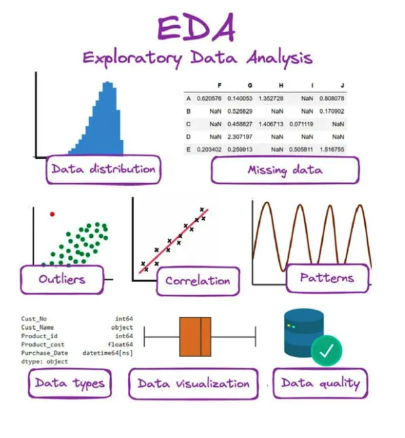

In the previous lesson, we viewed data as a sample from an underlying process, shaped by sampling variability and irreducible noise. That perspective explains why real-world datasets are messy. In this lesson, we focus on how to extract structure from that data.

## Load the Data

We begin by loading the dataset. This dataset is a simplified version of the Zillow data, designed to make exploration and interpretation more manageable. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename = "zillow_housing_data.csv"
df = pd.read_csv(filename)

### 2.1: Preliminary EDA

We first examine the size, structure, and basic properties of the dataset, including the target variable, feature types, and the presence of missing values.


https://www.kaggle.com/datasets/paultimothymooney/zillow-house-price-data/data



### Zillow Housing Dataset: Feature Set

0. **parcel_id**: Unique identifier for the property parcel.
1. **living_area_sqft**: Finished living area used for residential purposes (square feet).
2. **total_finished_sqft**: Total finished area of the property (square feet).
3. **lot_size_sqft**: Total land area of the property (square feet).
4. **room_count**: Total number of rooms in the property.
5. **bedroom_count**: Number of bedrooms.
6. **bathroom_count**: Number of bathrooms.
7. **calculated_bath_count**: Calculated number of bathrooms, including fractional values.
8. **building_quality**: Numeric rating of the building’s construction quality (ordered scale).
9. **landuse_type**: Identifier for the property’s land use category.
10. **zoning_description**: Text description of the property’s zoning classification.
11. **heating_system_type**: Identifier for the type of heating system.
12. **basement_sqft**: Finished area of the basement (square feet).
13. **latitude**: Latitude coordinate of the property location.
14. **longitude**: Longitude coordinate of the property location.
15. **fips**: Code identifying the county (FIPS standard).
16. **year_built**: Year the property was constructed.
17. **sale_price**: Final sale price of the property **(target variable).**


The task is a **regression problem,** predicting the `sale_price` from the other features. 

Get **info** about types and missing (null) values for each feature.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   parcel_id              77613 non-null  int64  
 1   living_area_sqft       73923 non-null  float64
 2   total_finished_sqft    77378 non-null  float64
 3   lot_size_sqft          69321 non-null  float64
 4   room_count             77579 non-null  float64
 5   bedroom_count          77579 non-null  float64
 6   bathroom_count         77579 non-null  float64
 7   calculated_bath_count  76963 non-null  float64
 8   building_quality       49809 non-null  float64
 9   landuse_type           77579 non-null  float64
 10  zoning_description     50476 non-null  object 
 11  heating_system_type    49571 non-null  float64
 12  basement_sqft          50 non-null     float64
 13  latitude               77579 non-null  float64
 14  longitude              77579 non-null  float64
 15  fi

Display the top 10 samples.

In [3]:
df.head(10)

,parcel_id,living_area_sqft,total_finished_sqft,lot_size_sqft,room_count,bedroom_count,bathroom_count,calculated_bath_count,building_quality,landuse_type,zoning_description,heating_system_type,basement_sqft,latitude,longitude,fips,year_built,sale_price
0,14297519,3100.0,3100.0,4506.0,0.0,4.0,3.5,3.5,NaN,261.0,NaN,NaN,NaN,33634931.0,-117869207.0,6059.0,1998.0,1023282.0
1,17052889,1465.0,1465.0,12647.0,5.0,2.0,1.0,1.0,NaN,261.0,NaN,NaN,NaN,34449266.0,-119281531.0,6111.0,1967.0,464000.0
2,14186244,1243.0,1243.0,8432.0,6.0,3.0,2.0,2.0,NaN,261.0,NaN,NaN,NaN,33886168.0,-117823170.0,6059.0,1962.0,564778.0
3,12177905,2376.0,2376.0,13038.0,0.0,4.0,3.0,3.0,8.0,261.0,LCR110000*,2.0,NaN,34245180.0,-118240722.0,6037.0,1970.0,145143.0
4,10887214,1312.0,1312.0,278581.0,0.0,3.0,3.0,3.0,8.0,266.0,LAR3,2.0,NaN,34185120.0,-118414640.0,6037.0,1964.0,119407.0
5,17143294,1492.0,1492.0,903.0,6.0,3.0,2.0,2.0,NaN,266.0,NaN,NaN,NaN,34230044.0,-118993991.0,6111.0,1982.0,331064.0
6,12095076,2962.0,2962.0,63000.0,0.0,4.0,3.0,3.0,9.0,261.0,PSR2,2.0,NaN,34145202.0,-118179824.0,6037.0,1950.0,773303.0
7,12069064,738.0,738.0,4214.0,0.0,2.0,1.0,1.0,5.0,261.0,GLR4YY,NaN,NaN,34149214.0,-118239357.0,6037.0,1922.0,218552.0
8,12790562,3039.0,3039.0,20028.0,0.0,4.0,3.0,3.0,9.0,261.0,WHRE20000*,2.0,NaN,33960230.0,-118006914.0,6037.0,1970.0,220583.0
9,11542646,1290.0,1290.0,54048.0,0.0,2.0,3.0,3.0,8.0,266.0,LAR3,2.0,NaN,33998800.0,-118416000.0,6037.0,1980.0,371361.0


#### Initial Observations 

From this preliminary examination, several observations stand out: 

- The dataset contains 77,613 observations and 18 features. 

- The features include a mixture of numerical measurements, identifiers, codes, and categorical information. 

- Several features contain substantial missing data. 

- The target variable (`sale_price`) is nearly complete. 

### 2.2: Understanding Feature Types

**Step 1: Examine Data Types and Missing Values**

Use `info()` to and `select_dtypes` to identify:

* numeric vs object types
* presence of missing values

We can also use Pandas to quickly separate features by their stored data types. This provides a useful starting point, but it does not fully determine how features should be interpreted.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   parcel_id              77613 non-null  int64  
 1   living_area_sqft       73923 non-null  float64
 2   total_finished_sqft    77378 non-null  float64
 3   lot_size_sqft          69321 non-null  float64
 4   room_count             77579 non-null  float64
 5   bedroom_count          77579 non-null  float64
 6   bathroom_count         77579 non-null  float64
 7   calculated_bath_count  76963 non-null  float64
 8   building_quality       49809 non-null  float64
 9   landuse_type           77579 non-null  float64
 10  zoning_description     50476 non-null  object 
 11  heating_system_type    49571 non-null  float64
 12  basement_sqft          50 non-null     float64
 13  latitude               77579 non-null  float64
 14  longitude              77579 non-null  float64
 15  fi

In [5]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numerical features: {num_cols}.\n")

print(f"Categorical features: {cat_cols}")

Numerical features: ['parcel_id', 'living_area_sqft', 'total_finished_sqft', 'lot_size_sqft', 'room_count', 'bedroom_count', 'bathroom_count', 'calculated_bath_count', 'building_quality', 'landuse_type', 'heating_system_type', 'basement_sqft', 'latitude', 'longitude', 'fips', 'year_built', 'sale_price'].

Categorical features: ['zoning_description']


#### Initial Observations 

Several observations stand out: 

- Some features appear to be identifiers or administrative codes rather than measurements.

- Most features are stored numerically

- `zoning_description` is the only feature stored as text. 

- Several features contain substantial missing data. 

- `basement_sqft` contains very few non-missing values and may not be useful for analysis. 

**Step 2: Visual Inspection of Distributions**

For **numeric features** we use histograms to examine the shape and structure of numerical features. This helps distinguish between continuous and discrete variables, identify distributions and outliers, and detect patterns that may not be obvious from summary statistics alone.

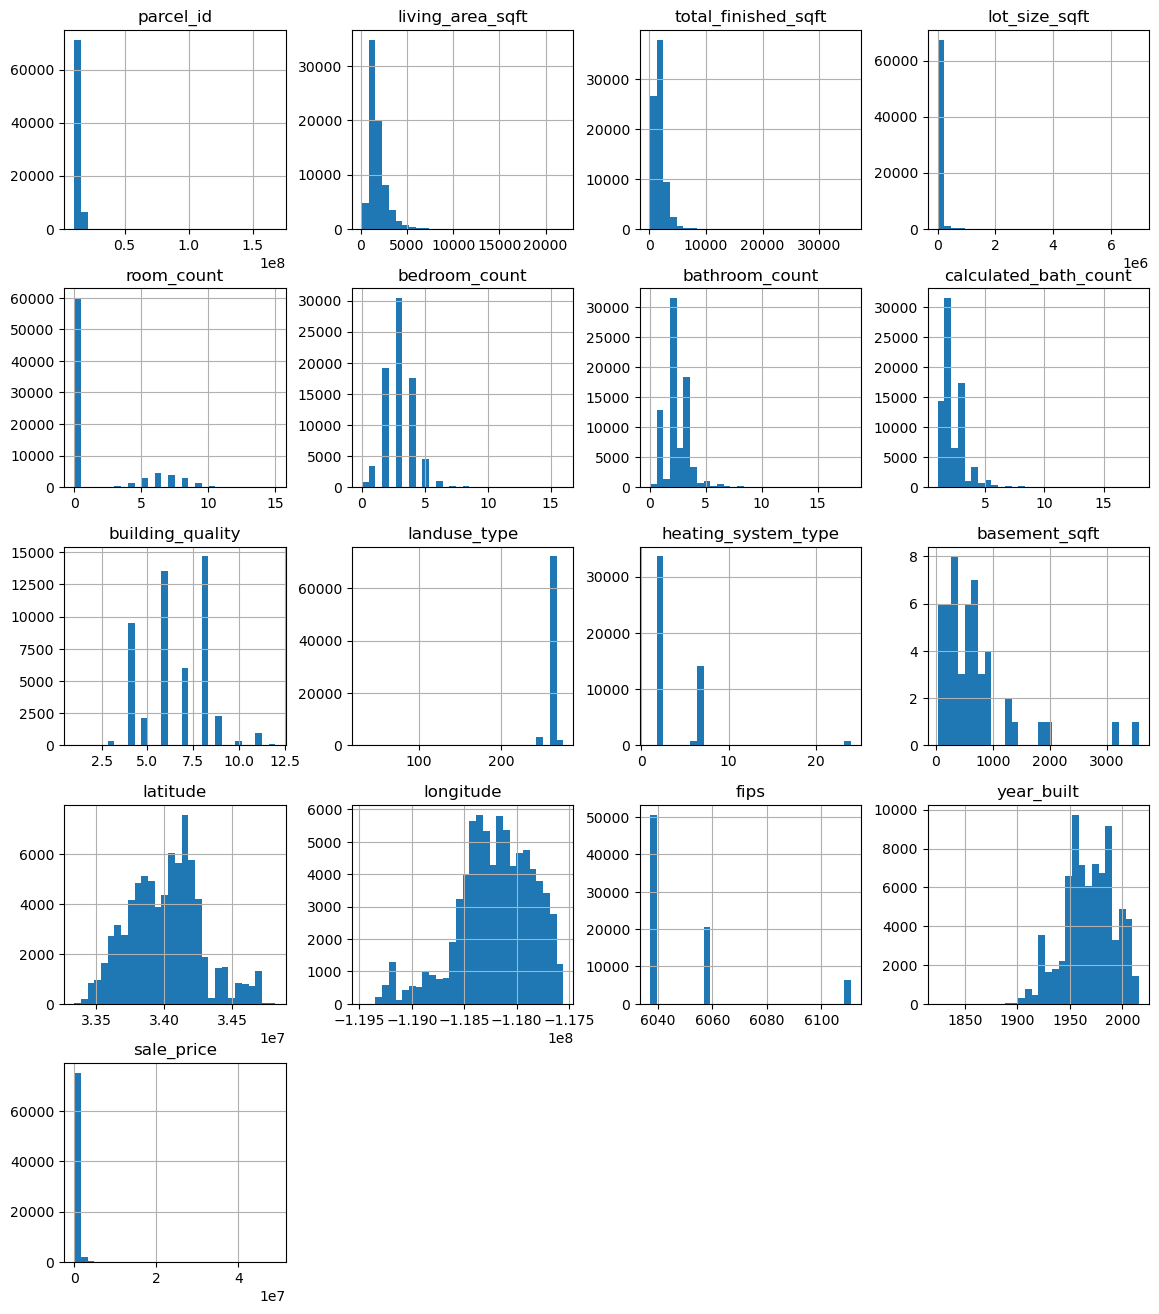

In [6]:
df.hist(figsize=(14, 16), bins=30);

#### Observations 

Several patterns emerge from the histograms: 

- Features such as `living_area_sqft`, `total_finished_sqft`, `lot_size_sqft`, `latitude`, and `longitude` appear to vary continuously over a broad range of values. 

- Features such as `room_count`, `bedroom_count`, `bathroom_count`, and `year_built` take on a limited set of integer values, suggesting discrete numerical variables. 

- Several variables exhibit substantial right skew and extreme values, particularly `sale_price`, `living_area_sqft`, and `lot_size_sqft`. 

- Some numerically stored variables, including `landuse_type`, `heating_system_type`, and `fips`, appear to represent categories rather than measurements. 

- The distribution of `year_built` suggests that properties are concentrated in more recent decades. 

- A surprisingly large number of properties have `room_count` = 0, which warrants further investigation. 

**Step 3: Count Distinct Values**

In [7]:
df.nunique().sort_values(ascending=False)

parcel_id                77414
latitude                 64038
longitude                62461
sale_price               50949
lot_size_sqft            18848
total_finished_sqft       4972
living_area_sqft          4868
zoning_description        1907
year_built                 136
basement_sqft               43
bathroom_count              22
calculated_bath_count       21
room_count                  16
bedroom_count               16
landuse_type                13
building_quality            12
heating_system_type         10
fips                         3
dtype: int64

In [8]:
# Give a frequency list in descending order of the first 20 labels

df["zoning_description"].value_counts().head(20)

zoning_description
LAR1       6766
LAR3       2450
LARS       1394
LBR1N      1225
LARD1.5    1132
LAR2       1033
SCUR2       957
LARD2       852
LARA        654
LARE11      629
LARE15      571
TORR-LO     545
LCR1YY      494
SCUR3       462
LAR4        410
LKR1YY      381
LARD3       374
PSR6        346
LCR1*       310
LCA11*      300
Name: count, dtype: int64

#### Observations 


Several patterns emerge: 

- `parcel_id` contains nearly one unique value per observation, indicating that it functions as an identifier. 

- `latitude`, `longitude`, and `sale_price` contain many distinct values, consistent with continuous numerical variables. 

- `room_count`, `bedroom_count`, and `bathroom_count` contain relatively few values, consistent with discrete numerical variables. 

- `landuse_type`, `heating_system_type`, and `fips` contain only a small number of values despite being stored numerically, suggesting that they represent coded categories. 

- `building_quality` contains only twelve distinct values, indicating a possible ordinal variable. 

- `zoning_description` contains 1,907 distinct categories, demonstrating that categorical variables can sometimes have very large numbers of possible values. Such high-cardinality categorical features often require special consideration during preprocessing and modeling. 

**Step 4: Interpret Meaning (Critical Step)**

The final classification depends on how the feature is **used**, not just how it is stored. This may depend on any documentation that came with the dataset, or on domain knowledge. 

* Does the value represent a **quantity**? → Numerical
* Does it represent a **category or label**? → Categorical
* Is there a **natural ordering**? → Ordinal
* Is it just an **identifier**? → Categorical (but typically not useful)

To classify a feature correctly, we combine information from its stored data type, distribution, number of distinct values, and documented meaning. This step is essential because variables that appear similar in raw data may represent very different concepts. 

For example, `living_area_sqft` is a measurement, while `fips` is a geographic code. Likewise, `building_quality` is stored numerically but represents an ordered set of categories. 

 

Using this information, we can now assign each feature to its final classification. 

 

**Step 5: Final Classification**

Based on all the above, we assign each feature to one of the four types:

| Feature                  | Continuous | Discrete | Nominal | Ordinal | Comments |
|------------------------|:----------:|:--------:|:-------:|:-------:|----------|
| parcel_id               |            |          | X        |          | Identifier (not useful for modeling) |
| living_area_sqft        | X          |          |          |          | Outliers? |
| total_finished_sqft     | X          |          |          |          | Outliers? |
| lot_size_sqft           | X          |          |          |          | Outliers? |
| room_count              |            | X        |          |          | Why 0s? |
| bedroom_count           |            | X        |          |          | Outliers?|
| bathroom_count          |            | X        |          |          | Outliers?|
| calculated_bath_count   |            | X        |          |          | Includes fractional values |
| building_quality        |            |          |          | X        | Ordered scale |
| landuse_type            |            |          | X        |          | Categorical code |
| zoning_description      |            |          | X        |          | Obscure text labels|
| heating_system_type     |            |          | X        |          | Categorical code |
| basement_sqft           | X          |          |          |          | Mostly null |
| latitude                | X          |          |          |          | Spatial variable |
| longitude               | X          |          |          |          | Spatial variable |
| fips                    |            |          | X        |          | Categorical identifier |
| year_built              |            | X         |          |          | Shows temporal aspects |
| sale_price              | X          |          |          |          | Target variable |

This classification will guide how we summarize, visualize, and prepare each feature for modeling.



## 2.3: Exploring Feature Distributions (Univariate EDA)

Descriptive statistics are provided for all numeric features by  `.describe()`, which reports statistics such as the mean, standard deviation, range, and quartiles. 

The 25%, 50%, and 75% rows correspond to the first quartile, median, and third quartile, indicating where the lower 25%, 50%, and 75% of the data lie.

In [9]:
df.describe()

,parcel_id,living_area_sqft,total_finished_sqft,lot_size_sqft,room_count,bedroom_count,bathroom_count,calculated_bath_count,building_quality,landuse_type,heating_system_type,basement_sqft,latitude,longitude,fips,year_built,sale_price
count,7.761300e+04,73923.000000,77378.000000,6.932100e+04,77579.000000,77579.000000,77579.000000,76963.000000,49809.000000,77579.000000,49571.000000,50.000000,7.757900e+04,7.757900e+04,77579.000000,77309.000000,7.757800e+04
mean,1.300781e+07,1760.284553,1784.935421,2.997344e+04,1.476276,3.053223,2.298496,2.316392,6.533779,261.824476,3.921749,679.720000,3.400837e+07,-1.182037e+08,6048.814151,1968.611507,4.901506e+05
std,3.518717e+06,934.352566,954.250373,1.233050e+05,2.823686,1.140480,0.996732,0.979689,1.722062,5.141596,3.594780,689.703546,2.652873e+05,3.594085e+05,20.747252,23.793171,6.537979e+05
min,1.071186e+07,128.000000,128.000000,2.360000e+02,0.000000,0.000000,0.000000,1.000000,1.000000,31.000000,1.000000,38.000000,3.333953e+07,-1.194754e+08,6037.000000,1824.000000,1.000000e+03
25%,1.153821e+07,1172.000000,1182.000000,5.700000e+03,0.000000,2.000000,2.000000,2.000000,6.000000,261.000000,2.000000,273.000000,3.381463e+07,-1.184150e+08,6037.000000,1953.000000,2.068985e+05
50%,1.253004e+07,1523.000000,1542.000000,7.206000e+03,0.000000,3.000000,2.000000,2.000000,6.000000,261.000000,2.000000,515.000000,3.402200e+07,-1.181810e+08,6037.000000,1970.000000,3.588785e+05
75%,1.421101e+07,2075.000000,2112.000000,1.183700e+04,0.000000,4.000000,3.000000,3.000000,8.000000,266.000000,7.000000,796.500000,3.417431e+07,-1.179286e+08,6059.000000,1987.000000,5.690000e+05
max,1.676893e+08,21929.000000,35640.000000,6.971010e+06,15.000000,16.000000,18.000000,18.000000,12.000000,275.000000,24.000000,3560.000000,3.481877e+07,-1.175546e+08,6111.000000,2016.000000,4.906124e+07


The difference between the 75% and 25% values is called the **interquartile range (IQR)** and measures the spread of the middle 50% of the data. Values far outside this range may indicate potential outliers.

**Boxplots** provide a graphical summary of this information, showing the quartiles, the median, and the range of typical values. Observations that fall more than 1.5×IQR below the first quartile or above the third quartile are often flagged as outliers.


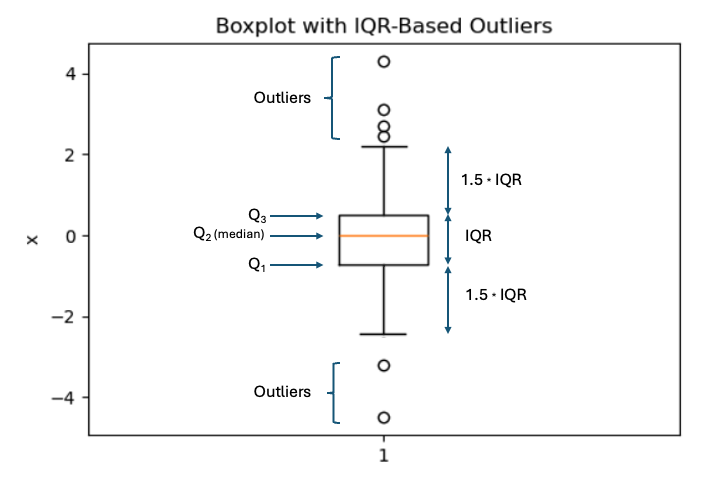

We will draw boxplots for numeric features only. 

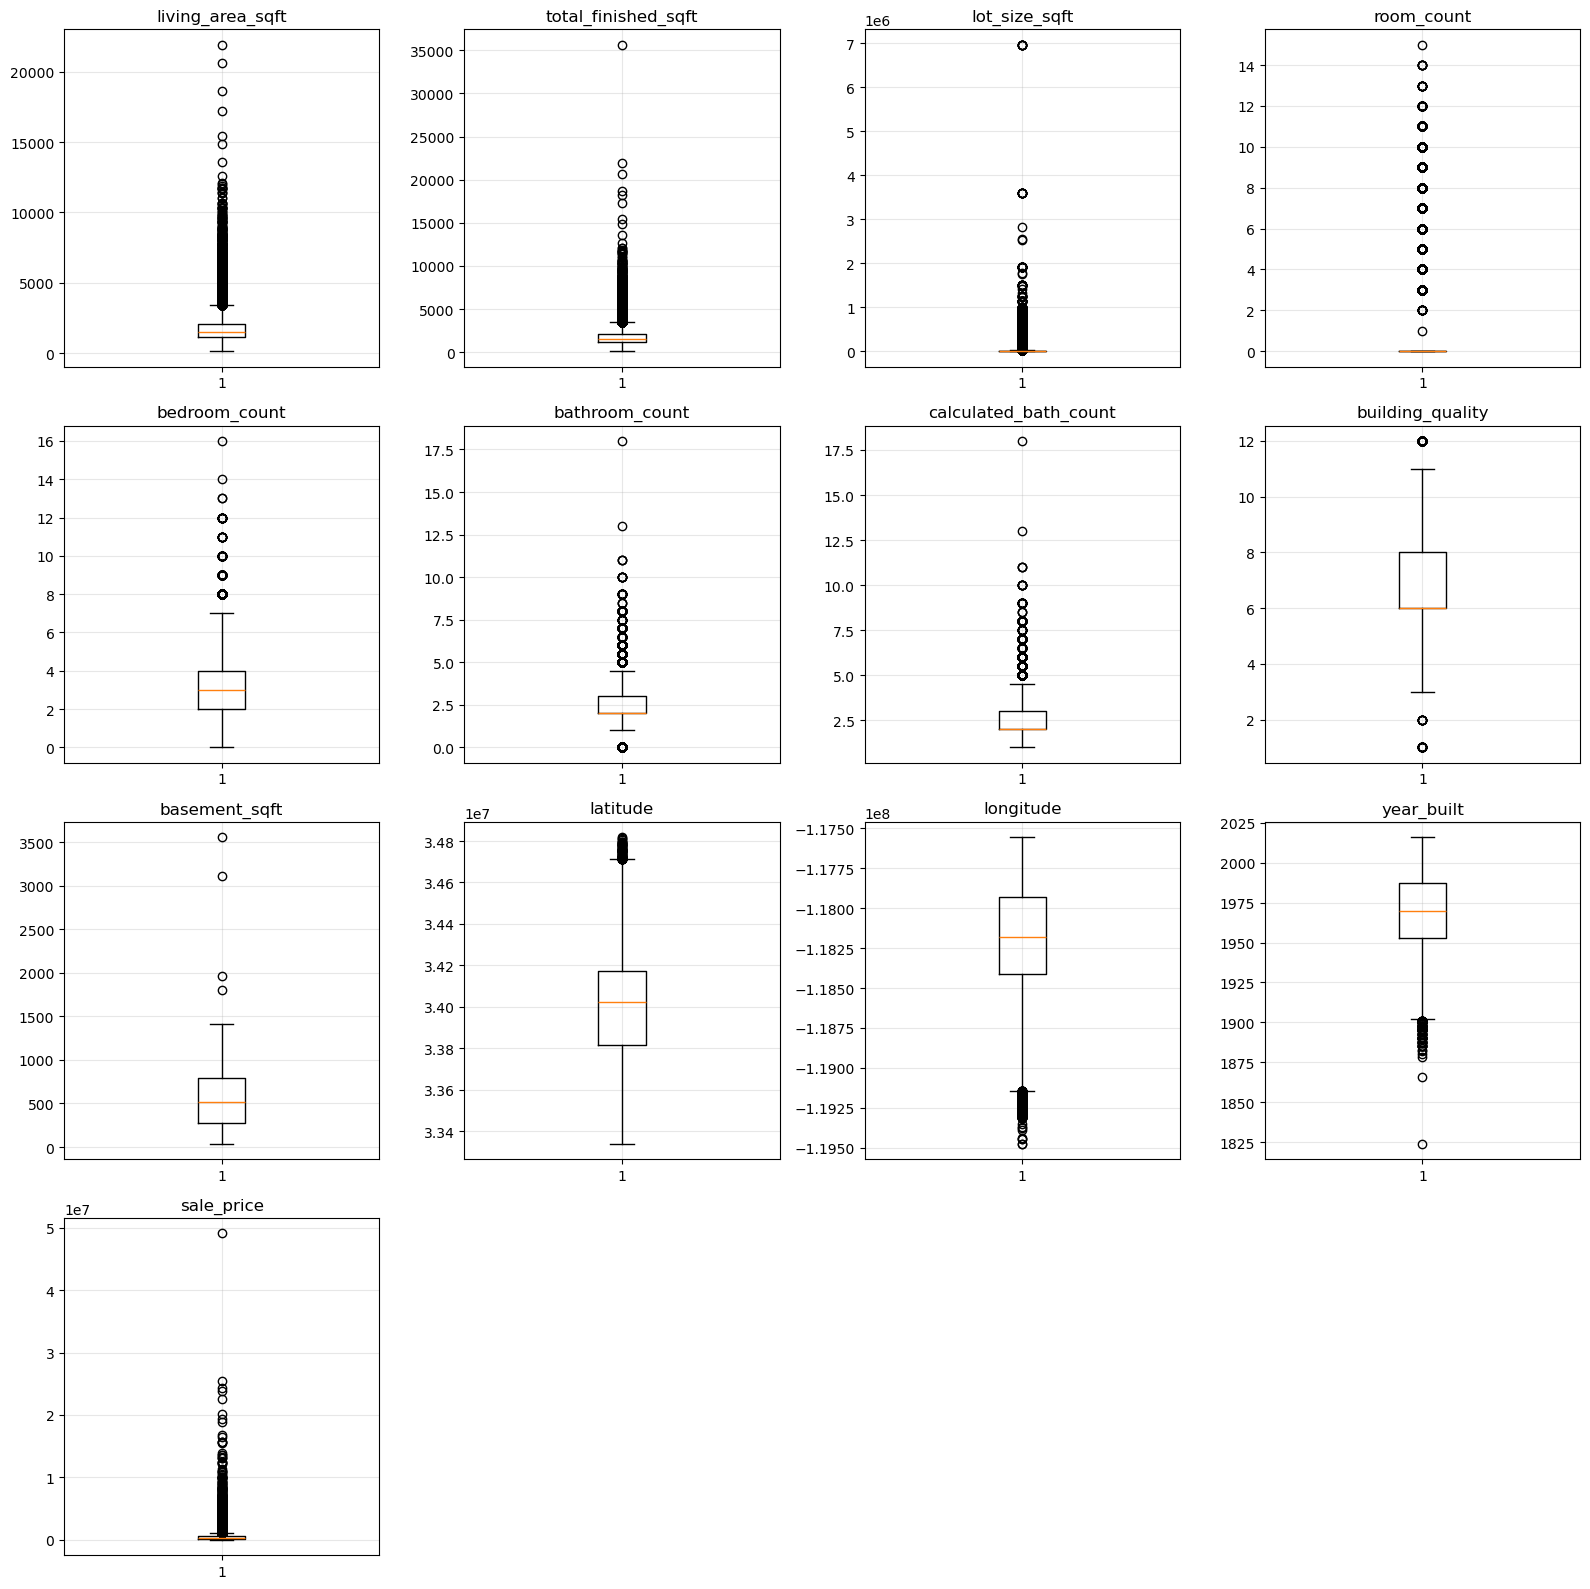

In [10]:
import matplotlib.pyplot as plt

# Define columns to exclude (categorical codes / identifiers)
exclude_cols = ["parcel_id", "landuse_type", "heating_system_type", "fips"]

# Select numeric columns and drop excluded ones
numeric_cols = df.select_dtypes(include="number").columns
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

# Layout: 4 across
ncols = 4
nrows = (len(numeric_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    vals = df[col].dropna()
    ax.boxplot(vals, vert=True, showfliers=True)
    ax.set_title(col)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Observations 

Several features (`living_area_sqft`, `total_finished_sqft`, `lot_size_sqft`, and `sale_price`) exhibit substantial right skew with long upper tails, indicating that most observations are concentrated at lower values.  

The boxplots reveal numerous observations beyond the upper whiskers, suggesting the presence of many potential outliers under the IQR rule.  

Discrete variables such as `room_count`, `bedroom_count`, `bathroom_count`, and `calculated_bath_count` exhibit distinct integer levels, reinforcing their classification as discrete numerical features.  

Features such as `building_quality`, `latitude`, `longitude`, and `year_built` display more concentrated and structured distributions, with fewer extreme observations.  

Several variables contain observations that are unusually far from the bulk of the data. These may represent data quality issues, rare but legitimate cases, or important characteristics of the underlying population, and therefore warrant further investigation. 




## 2.4: Relationships Between Variables (Multivariate EDA)

To understand how variables relate to one another, we examine pairwise relationships between features. 

Our first visualization uses a **pairplot,** which provides a compact way to view multiple relationships at once. For a selected set of numerical features, a pairplot displays a grid of plots in which each row and column corresponds to one variable. Off the diagonal, each cell shows a scatterplot for a pair of variables, allowing us to identify patterns such as linear relationships, clusters, and outliers.
Along the diagonal, instead of plotting a variable against itself, the pairplot shows the distribution of each individual feature (typically as a histogram or density plot). These plots summarize the shape, spread, and skewness of each variable.

Together, this layout allows us to examine both the distributions of individual variables and the relationships between pairs of variables in a single view.

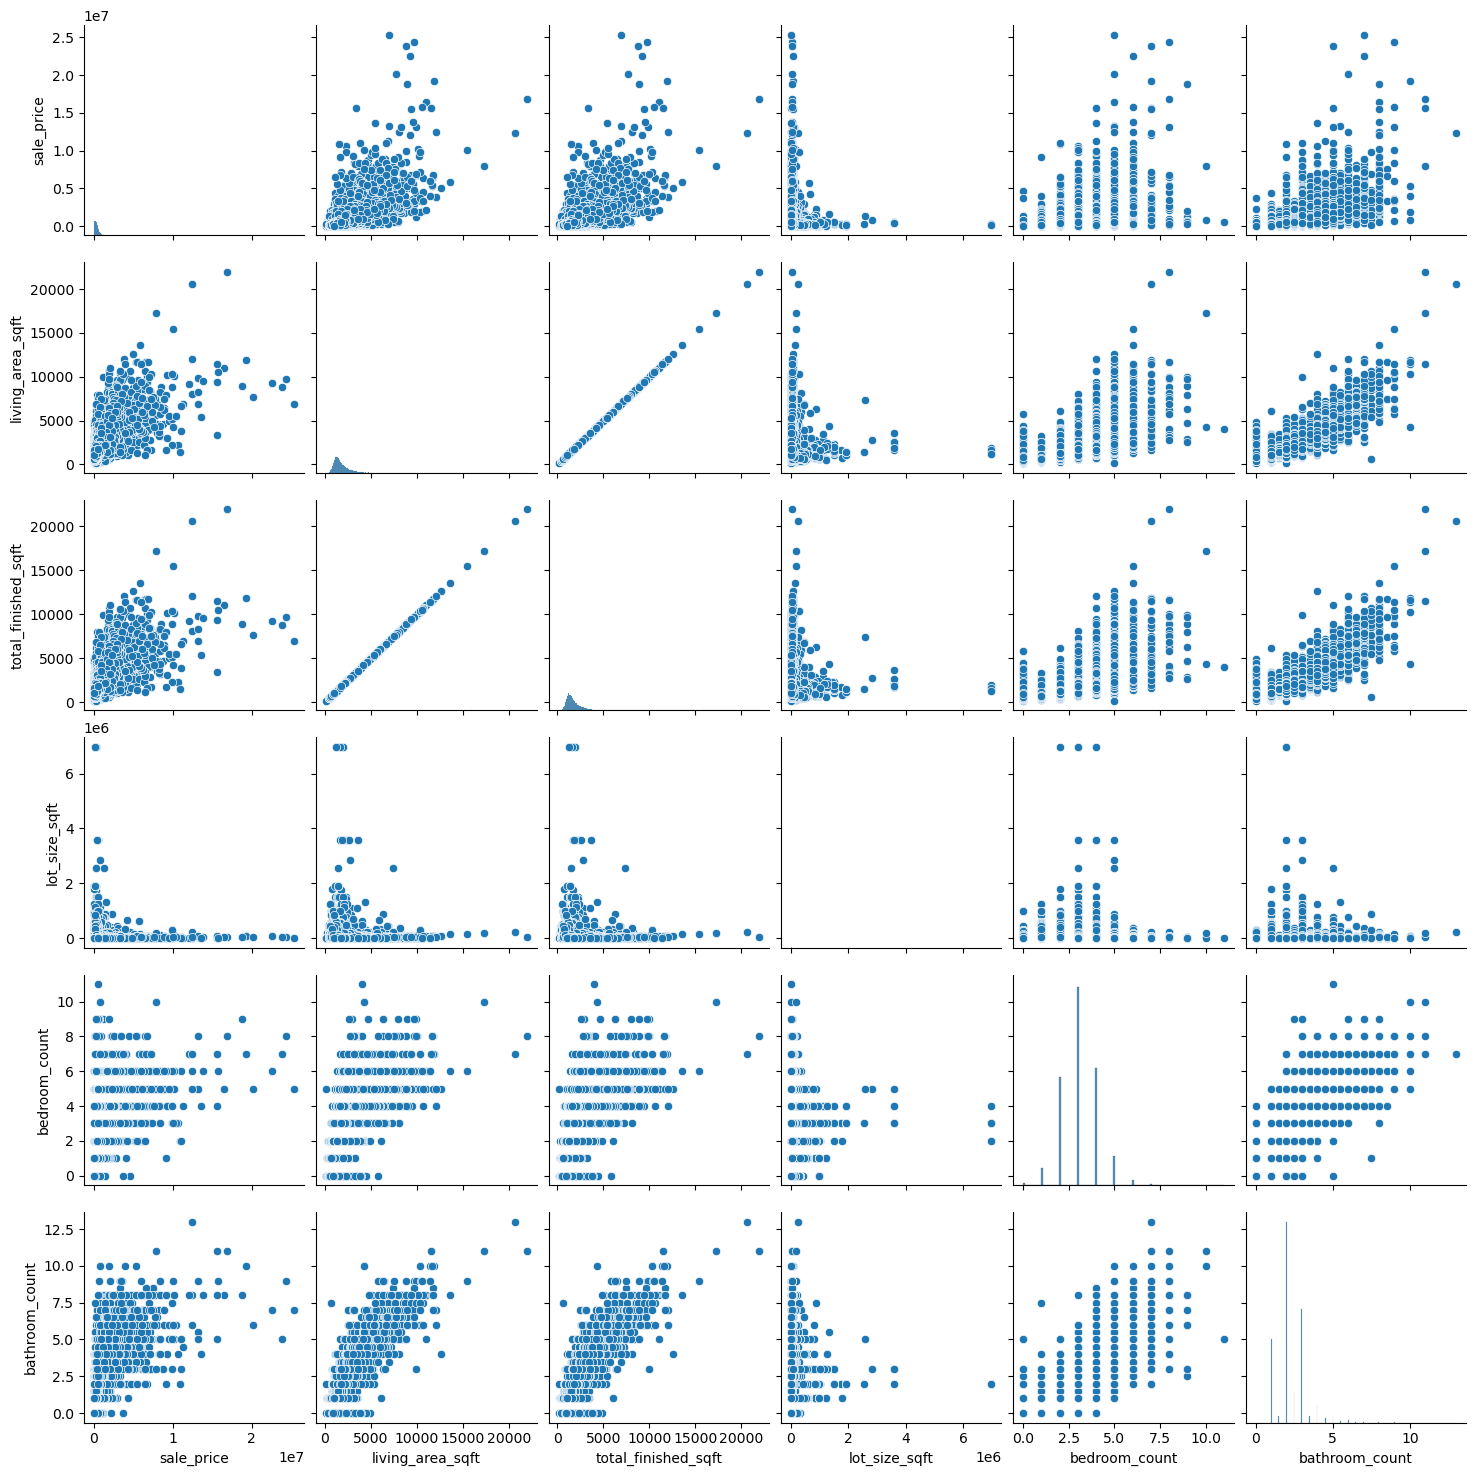

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select a subset of key numeric features
pairplot_cols = [
    "sale_price",
    "living_area_sqft",
    "total_finished_sqft",
    "lot_size_sqft",
    "bedroom_count",
    "bathroom_count"
]

# Drop missing values for these columns
df_pair = df[pairplot_cols].dropna()

# Create pairplot
sns.pairplot(df_pair, diag_kind="hist")

plt.show()

#### Observations 

- Several pairs of variables, particularly `living_area_sqft`, `total_finished_sqft`, and `sale_price`, exhibit clear positive associations, indicating that larger properties tend to sell for higher prices. 

- Some feature pairs display extremely strong linear relationships. For example, `living_area_sqft` and `total_finished_sqft` appear to - contain substantially overlapping information, suggesting that these variables measure closely related aspects of property size. 

- Discrete variables such as `room_count`, `bedroom_count`, and `bathroom_count` produce distinct horizontal and vertical bands, reflecting their integer-valued nature. 

- Several relationships exhibit increasing variability at larger values. In particular, the spread of sale_price tends to increase for larger homes, indicating that expensive properties are more heterogeneous than lower-priced properties. 

- The pairplot also highlights a small number of unusual observations that lie far from the bulk of the data, consistent with the potential outliers identified in the previous section. 

- Overall, the pairplot reveals substantial structure in the dataset and helps identify variables that may be strongly related, largely independent, or worthy of further investigation. 

 


Our second visualization uses a **correlation matrix,** which summarizes the strength of linear relationships between pairs of variables. Each entry in the matrix represents the correlation coefficient between two features, ranging from −1 to 1.

The matrix is often visualized as a heatmap, allowing us to quickly identify pairs of variables that are strongly related or largely independent.

,parcel_id,living_area_sqft,total_finished_sqft,lot_size_sqft,room_count,bedroom_count,bathroom_count,calculated_bath_count,building_quality,landuse_type,heating_system_type,basement_sqft,latitude,longitude,fips,year_built,sale_price
parcel_id,1.000000,0.036168,0.026288,-0.084334,0.336946,0.006812,0.003232,0.015360,-0.047073,0.033157,0.108884,0.368308,-0.164762,-0.014744,0.458412,0.141090,0.012496
living_area_sqft,0.036168,1.000000,1.000000,-0.051822,0.118470,0.661766,0.803920,0.809971,0.491833,-0.243274,-0.244989,0.277882,0.004705,-0.017402,0.077295,0.261451,0.606334
total_finished_sqft,0.026288,1.000000,1.000000,-0.053532,0.097045,0.631449,0.772863,0.807093,0.412710,-0.224098,-0.236837,0.277882,0.003992,-0.018227,0.059545,0.217400,0.583155
lot_size_sqft,-0.084334,-0.051822,-0.053532,1.000000,-0.085676,-0.110596,0.002482,0.001934,0.113346,0.145393,-0.141270,0.187221,0.087133,-0.061102,-0.081756,0.116037,-0.022497
room_count,0.336946,0.118470,0.097045,-0.085676,1.000000,0.166964,0.037741,0.029855,NaN,-0.018288,0.540267,0.556017,-0.200961,-0.059952,0.708797,0.075613,0.001960
bedroom_count,0.006812,0.661766,0.631449,-0.110596,0.166964,1.000000,0.635479,0.618283,0.108731,-0.268852,-0.162814,0.444727,0.069999,-0.008275,0.035135,0.047853,0.239326
bathroom_count,0.003232,0.803920,0.772863,0.002482,0.037741,0.635479,1.000000,1.000000,0.524034,-0.045047,-0.316391,0.542177,0.026617,-0.023752,0.016045,0.373210,0.461013
calculated_bath_count,0.015360,0.809971,0.807093,0.001934,0.029855,0.618283,1.000000,1.000000,0.523392,-0.121997,-0.316465,0.542177,0.020826,-0.025894,0.029357,0.373842,0.484819
building_quality,-0.047073,0.491833,0.412710,0.113346,NaN,0.108731,0.524034,0.523392,1.000000,0.308523,-0.627849,NaN,0.144623,-0.203266,NaN,0.571124,0.327590
landuse_type,0.033157,-0.243274,-0.224098,0.145393,-0.018288,-0.268852,-0.045047,-0.121997,0.308523,1.000000,-0.091353,0.004297,-0.020018,-0.005101,0.055384,0.348725,-0.035930


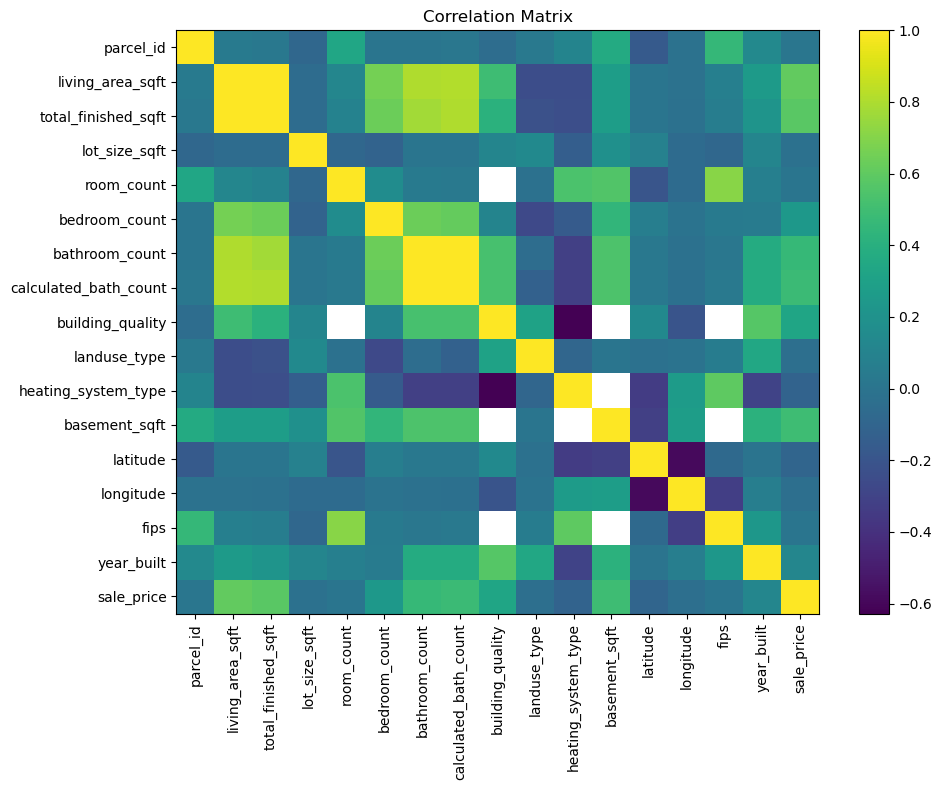

In [12]:
corr = df[num_cols].corr()
display(corr)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

#### Observations 

- Several variables exhibit strong positive correlations, particularly among size-related features such as `living_area_sqft` and `total_finished_sqft`, as well as between these features and `sale_price`. These relationships are consistent with the patterns observed in the pairplot. 

- Some feature pairs exhibit extremely high correlations. For example, `bathroom_count` and `calculated_bath_count` appear to measure nearly the same underlying characteristic and therefore contain substantially overlapping information. 

- Variables such as `bedroom_count`, `bathroom_count`, and `building_quality` exhibit moderate positive correlations with `sale_price`, indicating meaningful linear associations with the target variable. 

- Many feature pairs exhibit weak or near-zero correlations, suggesting little evidence of a linear relationship. However, a weak correlation does not necessarily imply that two variables are unrelated, as nonlinear relationships may still be present. 

- Overall, the correlation matrix provides a concise summary of the strongest linear relationships in the dataset and helps identify variables that appear closely related, largely independent, or worthy of further investigation. 

**Just for Fun: Display longitude and latitude on a map!**

In [13]:
# !pip install folium

In [15]:
# import folium

# # Create clean map dataframe
# df_map = df[["latitude", "longitude", "sale_price"]].dropna().copy()

# # Convert from scaled integers to degrees
# df_map["latitude"] = df_map["latitude"] / 1_000_000
# df_map["longitude"] = df_map["longitude"] / 1_000_000

# # Sample AFTER conversion
# df_map = df_map.sample(n=min(2000, len(df_map)), random_state=42)

# # Center map
# center_lat = df_map["latitude"].mean()
# center_lon = df_map["longitude"].mean()

# m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# # Add points
# for _, row in df_map.iterrows():
#     folium.CircleMarker(
#         location=[row["latitude"], row["longitude"]],
#         radius=2,
#         fill=True,
#         fill_opacity=0.6
#     ).add_to(m)

# m

## **3.1: Data Preparation, Refinement, and Feature Engineering**



#### **Data Preparation (Cleaning)**

Prepare the data so that it is usable.

- Remove non-informative features
- Remove samples with missing targets
- Remove samples with excessive missingness
- Remove features with excessive missingness
- Investigate potential data errors (optional)
  - Examine suspicious values and correct and
    remove them only when there is evidence that they are erroneous.
- Impute missing values
- Encode categorical variables

At this point, we have a clean dataset.

#### **Data Refinement (optional)**


These operations modify the dataset itself and should be guided by the characteristics of the data and the modeling objective.

- Remove or consolidate redundant features
- Detect and decide how to handle outliers
- Investigate potential duplicate records before deciding whether to remove them

Notice that these change which observations or variables are present, not their representation.

#### **Feature Engineering (optional)**

These techniques modify the representation of the predictors to improve model performance.

- Log transforms
- Polynomial features
- Other transformations (e.g., square root or exponential)
- Scaling and standardization
- Feature selection 

The usefulness of these techniques depends on both the dataset and the learning algorithm. Some models benefit substantially from particular transformations, while others are largely unaffected. As with other preprocessing decisions, their value should be assessed empirically by measuring the effect on model performance. We will examine feature selection in detail next week.

In preparation for next week's lesson on linear regression, we will prepare the Zillow dataset through "Remove or consolidate redundant features." Additional refinements, such as outlier removal or feature transformations, should generally be guided by the behavior of the intended learning algorithm rather than by assumptions made before modeling.


### **Data Preparation (Cleaning)**

**Remove non-informative or problematic features**
 

In [16]:
drop_cols = ["parcel_id", "fips"]
df_cleaned_1 = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("Remaining columns:")
print(list(df_cleaned_1.columns))

Remaining columns:
['living_area_sqft', 'total_finished_sqft', 'lot_size_sqft', 'room_count', 'bedroom_count', 'bathroom_count', 'calculated_bath_count', 'building_quality', 'landuse_type', 'zoning_description', 'heating_system_type', 'basement_sqft', 'latitude', 'longitude', 'year_built', 'sale_price']


**Remove samples with missing target values**


In [17]:
# Remove samples with missing target values

df_cleaned_2 = df_cleaned_1.dropna(subset=["sale_price"])

print(f"Removed {df_cleaned_1.shape[0]-df_cleaned_2.shape[0]} samples.")
print("After dropping rows with missing targets:", df_cleaned_2.shape)

df_cleaned_2.to_csv("df_cleaned_2.csv", index=False)

Removed 35 samples.
After dropping rows with missing targets: (77578, 16)


**Remove samples and features with too many missing or erroneous values**

> Missingness percentages are computed on the **original dataset** (before any features were removed). Otherwise, deleting features changes the percentage of missing values for every sample, making the cleaning process dependent on the order in which the steps are performed.

In [18]:
# Drop samples with excessive missingness

sample_missing_threshold = 0.30

# Compute missingness on the original dataset so that the
# percentage is not affected by features removed earlier.
row_missing_fraction = df.isnull().mean(axis=1)

# Apply the mask to the current dataframe
df_cleaned_3 = df_cleaned_2.loc[
    row_missing_fraction < sample_missing_threshold
].copy()

df_cleaned_3.to_csv("df_cleaned_3.csv", index=False)

print(f"Removed {df_cleaned_2.shape[0] - df_cleaned_3.shape[0]} samples.")
print("After dropping rows with excessive missingness:", df_cleaned_3.shape)

Removed 459 samples.
After dropping rows with excessive missingness: (77119, 16)


In [19]:
# Drop features with excessive missingness

feature_missing_threshold = 0.80   # drop features missing more than 80% of values

# Compute missingness on the original dataset so that the
# percentage is not affected by features removed earlier.
col_missing_fraction = df.isnull().mean()

# Determine which features to remove
cols_to_drop_missing = col_missing_fraction[
    col_missing_fraction > feature_missing_threshold
].index.tolist()

print("Columns dropped:", cols_to_drop_missing)

# Remove those features from the current cleaned dataset
df_cleaned_4 = df_cleaned_3.drop(columns=cols_to_drop_missing)

df_cleaned_4.to_csv("df_cleaned_4.csv", index=False)

df_cleaned = df_cleaned_4

print(f"Removed {len(cols_to_drop_missing)} features.")
print("After dropping features with excessive missingness:", df_cleaned_4.shape)

Columns dropped: ['basement_sqft']
Removed 1 features.
After dropping features with excessive missingness: (77119, 15)


**Impute remaining missing values**

After removing samples and features with excessive missingness, some missing values may still remain. Since most machine learning models cannot handle missing values directly, we must decide how to **fill in (impute)** these values in a reasonable way.

The goal of imputation is not to recover the true value—which is unknown—but to provide a sensible approximation that allows the model to learn from the data without introducing unnecessary bias.

Imputation strategies depend on:

* the **type of feature** (numerical vs categorical),
* the **distribution of the data** (e.g., symmetric vs skewed),
* and the **context or meaning** of the variable.


**Basic Imputation Methods**

| Method                       | Best For                            | Code Example                   | Pros                       | Cons                                    |
| ---------------------------- | ----------------------------------- | ------------------------------ | -------------------------- | --------------------------------------- |
| **Mean Imputation**          | Normally distributed numerical data | `df.fillna(df.mean())`         | Preserves mean; simple     | Distorts variance, weak for skewed data |
| **Median Imputation**        | Skewed numerical data               | `df.fillna(df.median())`       | Robust to outliers         | May not capture patterns                |
| **Mode Imputation**          | Categorical features                | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias                      |
| **Constant Value (e.g., 0)** | Special cases                       | `df.fillna(0)`                 | Simple and interpretable   | Can mislead model                       |
| **"Unknown" Category**       | Categorical features                | `df.fillna('Unknown')`         | Preserves data             | Adds artificial category                |

**We'll use** 
- Median imputation for numerical features
- "Unknown" category for categorical features

In [20]:
# Impute remaining missing values

target = "sale_price"

categorical_cols = [
    "zoning_description",
    "landuse_type",
    "heating_system_type",
]

# Keep only categorical columns that still exist in df
categorical_cols = [c for c in categorical_cols if c in df_cleaned.columns]

# All remaining numeric features except the target
numeric_cols = [
    c for c in df_cleaned.select_dtypes(include="number").columns
    if c != "sale_price" and c not in categorical_cols
]

print(f"Categorical Features: {categorical_cols}.")
print(f"Numeric Features: {numeric_cols}.\n")

df_imputed_1 = df_cleaned.copy()

# Step 1: numeric
for col in numeric_cols:
    df_imputed_1[col] = df_imputed_1[col].fillna(df_imputed_1[col].median())

# Step 2: categorical
df_imputed_2 = df_imputed_1.copy()

for col in categorical_cols:
    df_imputed_2[col] = df_imputed_2[col].fillna("Unknown")

df_imputed = df_imputed_2

print("Missing values before imputation:")
print(df_cleaned.isnull().sum().sort_values(ascending=False))

print("\nMissing values after imputation:")
print(df_imputed.isnull().sum().sort_values(ascending=False))

Categorical Features: ['zoning_description', 'landuse_type', 'heating_system_type'].
Numeric Features: ['living_area_sqft', 'total_finished_sqft', 'lot_size_sqft', 'room_count', 'bedroom_count', 'bathroom_count', 'calculated_bath_count', 'building_quality', 'latitude', 'longitude', 'year_built'].

Missing values before imputation:
heating_system_type      27548
building_quality         27312
zoning_description       26716
lot_size_sqft             8174
living_area_sqft          3202
calculated_bath_count      167
year_built                  64
total_finished_sqft          3
bathroom_count               0
room_count                   0
bedroom_count                0
landuse_type                 0
latitude                     0
longitude                    0
sale_price                   0
dtype: int64

Missing values after imputation:
living_area_sqft         0
total_finished_sqft      0
lot_size_sqft            0
room_count               0
bedroom_count            0
bathroom_count      

**Encode categorical variables**

We convert categorical variables into numeric form using one-hot encoding, so they can be used by machine learning models. Each category is represented by a separate binary feature indicating whether an observation belongs to that category.

Although landuse_type and heating_system_type are stored as numbers, they represent categorical labels rather than quantities, so we first treat them as categorical variables before encoding.

To avoid redundancy, we drop one category from each set of encoded variables, reducing multicollinearity while preserving the underlying information

> One-hot encoding produces k variables but only k−1 degrees of freedom, so we drop one category to avoid redundancy and ensure the model is well-defined.

In [21]:
# Encode categorical variables

df_encoded = df_imputed.copy()

categorical_cols = [
    "landuse_type",
    "heating_system_type",
    "zoning_description"
]

# Keep only columns that still exist
categorical_cols = [c for c in categorical_cols if c in df_encoded.columns]

# Convert numeric-coded categories to categorical type (optional but good practice)
for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype("category")

# One-hot encoding
df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_cols,
    drop_first=True   # avoids multicollinearity
)

print("Shape before encoding:", df_imputed.shape)
print("Shape after encoding:", df_encoded.shape)

Shape before encoding: (77119, 15)
Shape after encoding: (77119, 1940)


In [22]:
df_encoded.to_csv("zillow_preprocessed.csv", index=False)

### **Data Refinement (optional)**

At this point, the dataset is clean and ready for modeling. The remaining decisions depend on the goals of the project and the behavior of the chosen learning algorithm. Rather than applying them automatically, they should be guided by experiments with the model.

- Removing redundant features. Eliminating one of a pair of highly correlated features may simplify the model and make feature interpretation easier. Whether it improves predictive performance depends on the learning algorithm and should be evaluated empirically.
- Outlier detection and removal. Outliers can have very different effects depending on the modeling objective and the algorithm being used. Some models are highly sensitive to outliers, while others are relatively robust.

These refinements are therefore best considered after selecting a learning algorithm and evaluating its performance. They are not general-purpose data cleaning steps, but model-dependent decisions whose value should be confirmed experimentally.

**Address redundancy**

   * Remove or consolidate highly correlated features

> Note: Correlations are computed using `df_imputed`, the dataset immediately before one-hot encoding. This avoids creating thousands of dummy variables while still allowing us to identify highly correlated original features.

In [23]:
# Correlation matrix
corr_matrix = df_imputed.corr(numeric_only=True)

# Extract upper triangle (excluding diagonal)
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
               .stack()
               .reset_index()
)

corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']

# Sort by absolute correlation
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()

corr_pairs = corr_pairs.sort_values(
    by='abs_correlation',
    ascending=False
)

corr_pairs.head(20)

,feature_1,feature_2,correlation,abs_correlation
50,bathroom_count,calculated_bath_count,0.995532,0.995532
0,living_area_sqft,total_finished_sqft,0.953404,0.953404
16,total_finished_sqft,calculated_bath_count,0.796405,0.796405
15,total_finished_sqft,bathroom_count,0.788932,0.788932
5,living_area_sqft,calculated_bath_count,0.758284,0.758284
4,living_area_sqft,bathroom_count,0.753292,0.753292
14,total_finished_sqft,bedroom_count,0.648923,0.648923
42,bedroom_count,bathroom_count,0.622617,0.622617
43,bedroom_count,calculated_bath_count,0.615313,0.615313
11,living_area_sqft,sale_price,0.599026,0.599026


**Detect and Remove Outliers (optional)**


Outliers are observations whose values are unusually extreme compared with the rest of the dataset. They are often treated as potential problems because they can have a large influence on some machine learning algorithms, particularly linear regression. However, **outliers are not necessarily errors.** An observation may be unusual because of a data entry mistake, an equipment or measurement error, or simply because it represents a rare but legitimate real-world case.

In most cases, you can get better metrics by removing outliers, because it makes the dataset more homogeneous. 
But **whether outliers should be removed depends on the purpose of the model.** For example, if the goal is to predict the prices of typical residential homes, it may be reasonable to exclude a small number of luxury estates whose characteristics are unlike most properties. On the other hand, if the goal is to build a model for an online real estate marketplace, those high-end properties are an important part of the population and should be retained.

Outliers can also be defined in different ways. A single feature, such as sale_price, may contain unusually large values, but an observation can also be unusual only when many features are considered together. In this section, we illustrate both ideas by examining the distribution of sale prices and the distribution of multivariate Euclidean distances after standardizing the numerical features.

At this stage, **we will not remove any outliers.** Instead, our goal is simply to understand how they can be identified and how many observations would be considered extreme under different thresholds. We will revisit the question of whether removing outliers improves model performance after we have developed our first predictive model.


**Example: Outliers defined by target value**

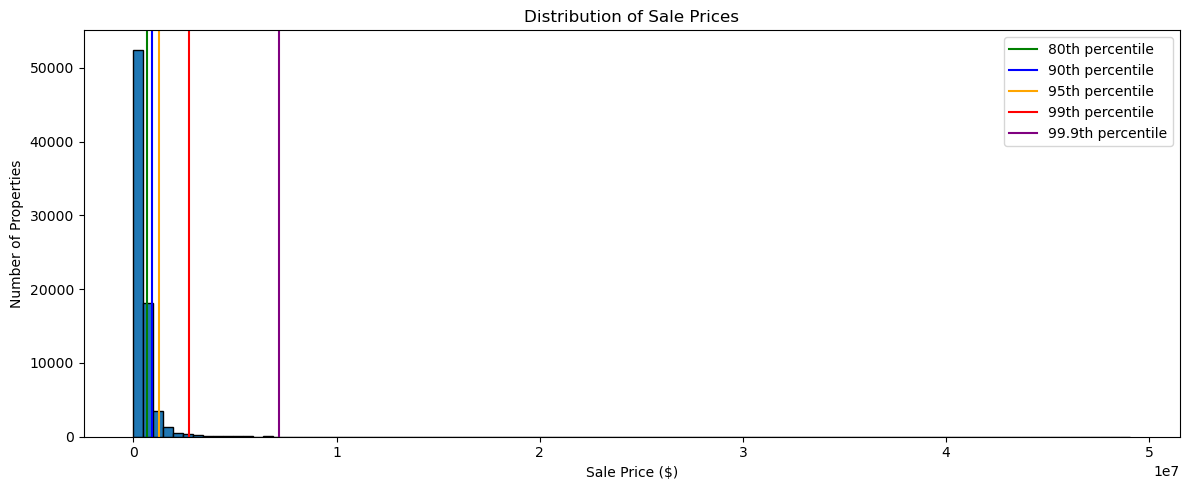

Sale Price Percentiles
----------------------
80% : $641,809
90% : $900,938
95% : $1,280,000
99% : $2,716,199
99.9% : $7,179,601


In [24]:
import numpy as np
import matplotlib.pyplot as plt

percentiles = [80, 90, 95, 99, 99.9]
colors = ["green", "blue", "orange", "red", "purple"]

prices = df_encoded["sale_price"]

plt.figure(figsize=(12, 5))
plt.hist(prices, bins=100, edgecolor="black")

for p, c in zip(percentiles, colors):
    value = np.percentile(prices, p)
    plt.axvline(
        value,
        color=c,
        linewidth=1.5,
        label=f"{p}th percentile"
    )

plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Properties")
plt.legend()
plt.tight_layout()
plt.show()

print("Sale Price Percentiles")
print("----------------------")
for p in percentiles:
    print(f"{p:>2}% : ${np.percentile(prices, p):,.0f}")

**Example: Outliers defined by Euclidean distance of all features from mean.**

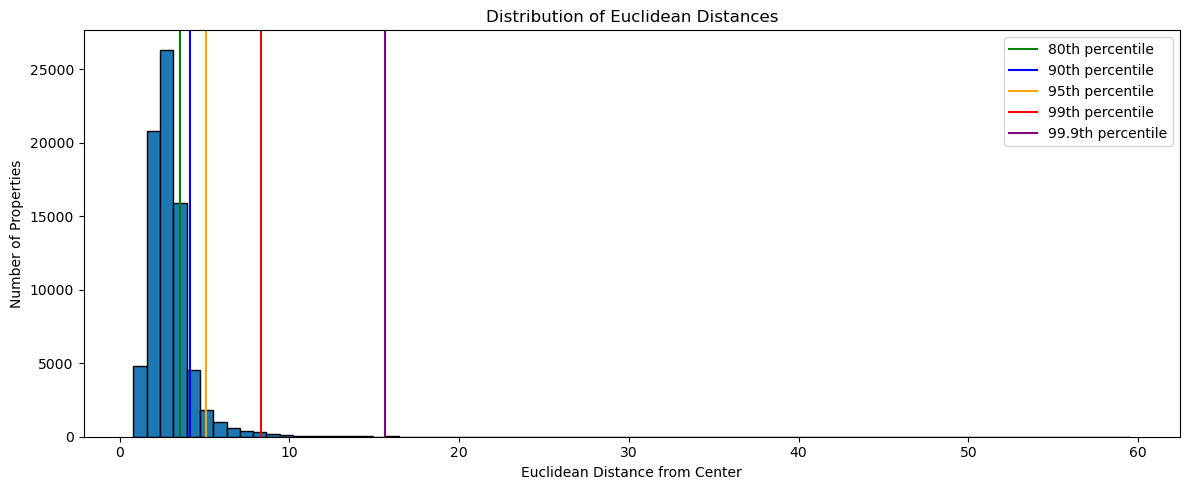

Euclidean Distance Percentiles
------------------------------
  80% : 3.53   (15,424 observations)
  90% : 4.12   (7,712 observations)
  95% : 5.06   (3,856 observations)
  99% : 8.31   (772 observations)
99.9% : 15.66   (78 observations)


In [25]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

percentiles = [80, 90, 95, 99, 99.9]
colors = ["green", "blue", "orange", "red", "purple"]

# Numeric predictors only
X = df_encoded.select_dtypes(include="number").drop(columns=["sale_price"])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Euclidean distance from the center
distances = np.linalg.norm(X_scaled, axis=1)

plt.figure(figsize=(12, 5))
plt.hist(distances, bins=75, edgecolor="black")

for p, c in zip(percentiles, colors):
    threshold = np.percentile(distances, p)
    plt.axvline(
        threshold,
        color=c,
        linewidth=1.5,
        label=f"{p}th percentile"
    )

plt.title("Distribution of Euclidean Distances")
plt.xlabel("Euclidean Distance from Center")
plt.ylabel("Number of Properties")
plt.legend()
plt.tight_layout()
plt.show()

print("Euclidean Distance Percentiles")
print("------------------------------")
for p in percentiles:
    threshold = np.percentile(distances, p)
    count = (distances > threshold).sum()
    print(f"{p:>4}% : {threshold:.2f}   ({count:,} observations)")

#### **Feature Engineering (optional)**


**Apply Feature Transformations (optional)**

In the previous steps, we addressed data quality issues such as missing values, redundancy, and outliers. We now consider whether the representation of the features themselves can be improved to better reflect the underlying structure of the data.

Several numerical features (`living_area_sqft`, `lot_size_sqft`) exhibit strong right skew, with a small number of very large values. A common approach is to apply transformations—most notably log scaling—to produce more symmetric distributions and reduce the influence of extreme values.

It is also natural to ask whether the target variable (`sale_price`) should be transformed. If the target has a multiplicative relationship with skewed features, transforming both the predictors and the target may improve model performance. However, predictions must then be converted back to the original dollar scale before evaluation metrics such as MAE and RMSE can be meaningfully interpreted.

In this lesson, however, **we do not apply feature transformations.** Instead, we defer that decision until the next lesson, when we have a predictive model and can evaluate their impact empirically.

However, to illustrate the effect of these transformations, we show the distributions of these features graphically. 

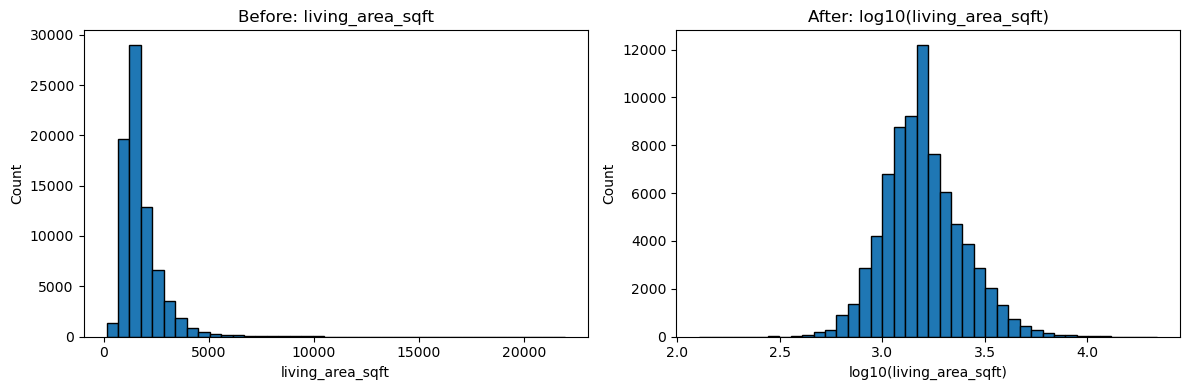

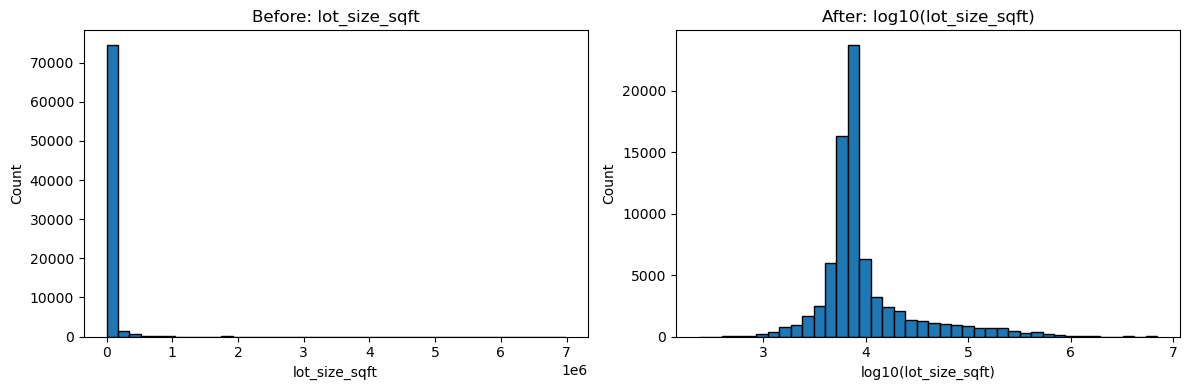

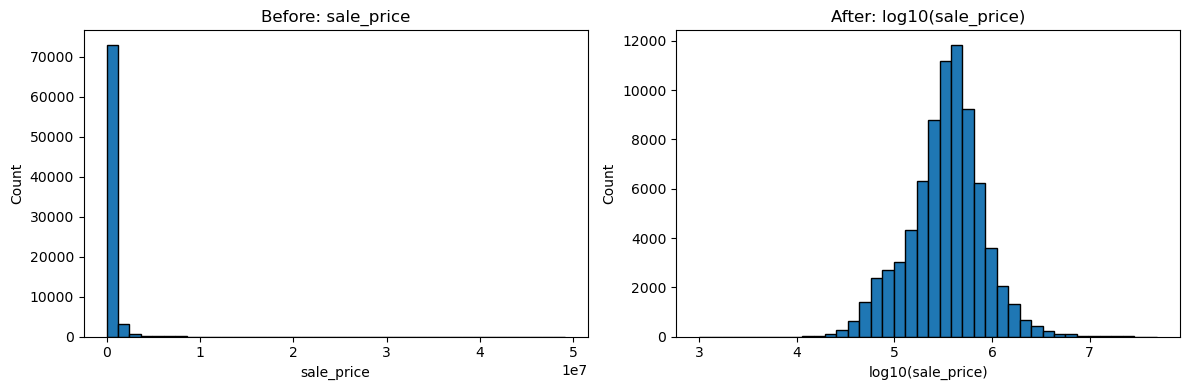

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Display original and log-transformed distributions
# --------------------------------------------------

log_columns = [
    "living_area_sqft",
    "lot_size_sqft",
    "sale_price",
]

log_columns = [c for c in log_columns if c in df_encoded.columns]

for col in log_columns:
    original = df_encoded[col].copy()
    transformed = np.log10(original)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].hist(original, bins=40, edgecolor="black")
    ax[0].set_title(f"Before: {col}")
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Count")

    ax[1].hist(transformed, bins=40, edgecolor="black")
    ax[1].set_title(f"After: log10({col})")
    ax[1].set_xlabel(f"log10({col})")
    ax[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

